## Loading Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler,LabelBinarizer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,recall_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_pipeline_imb

import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [39]:
import pandas as pd
data = pd.read_csv('Telco-Customer-Churn.csv')
df = data
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Exploratory Data Analysis

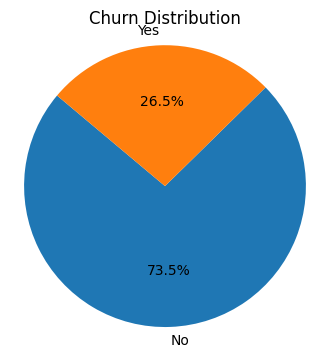

In [18]:
plt.figure(figsize=(4,4))
output_counts = data['Churn'].value_counts()
plt.pie(output_counts, labels=output_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Churn Distribution')
plt.axis('equal')
plt.show()


#### Observation:
    
The target column looks imbalanced - accuracy would not be a good metric to evaluate the model and we would need to apply balancing techniques like SMOTE while modeling

📦 Box plot for numerical features:


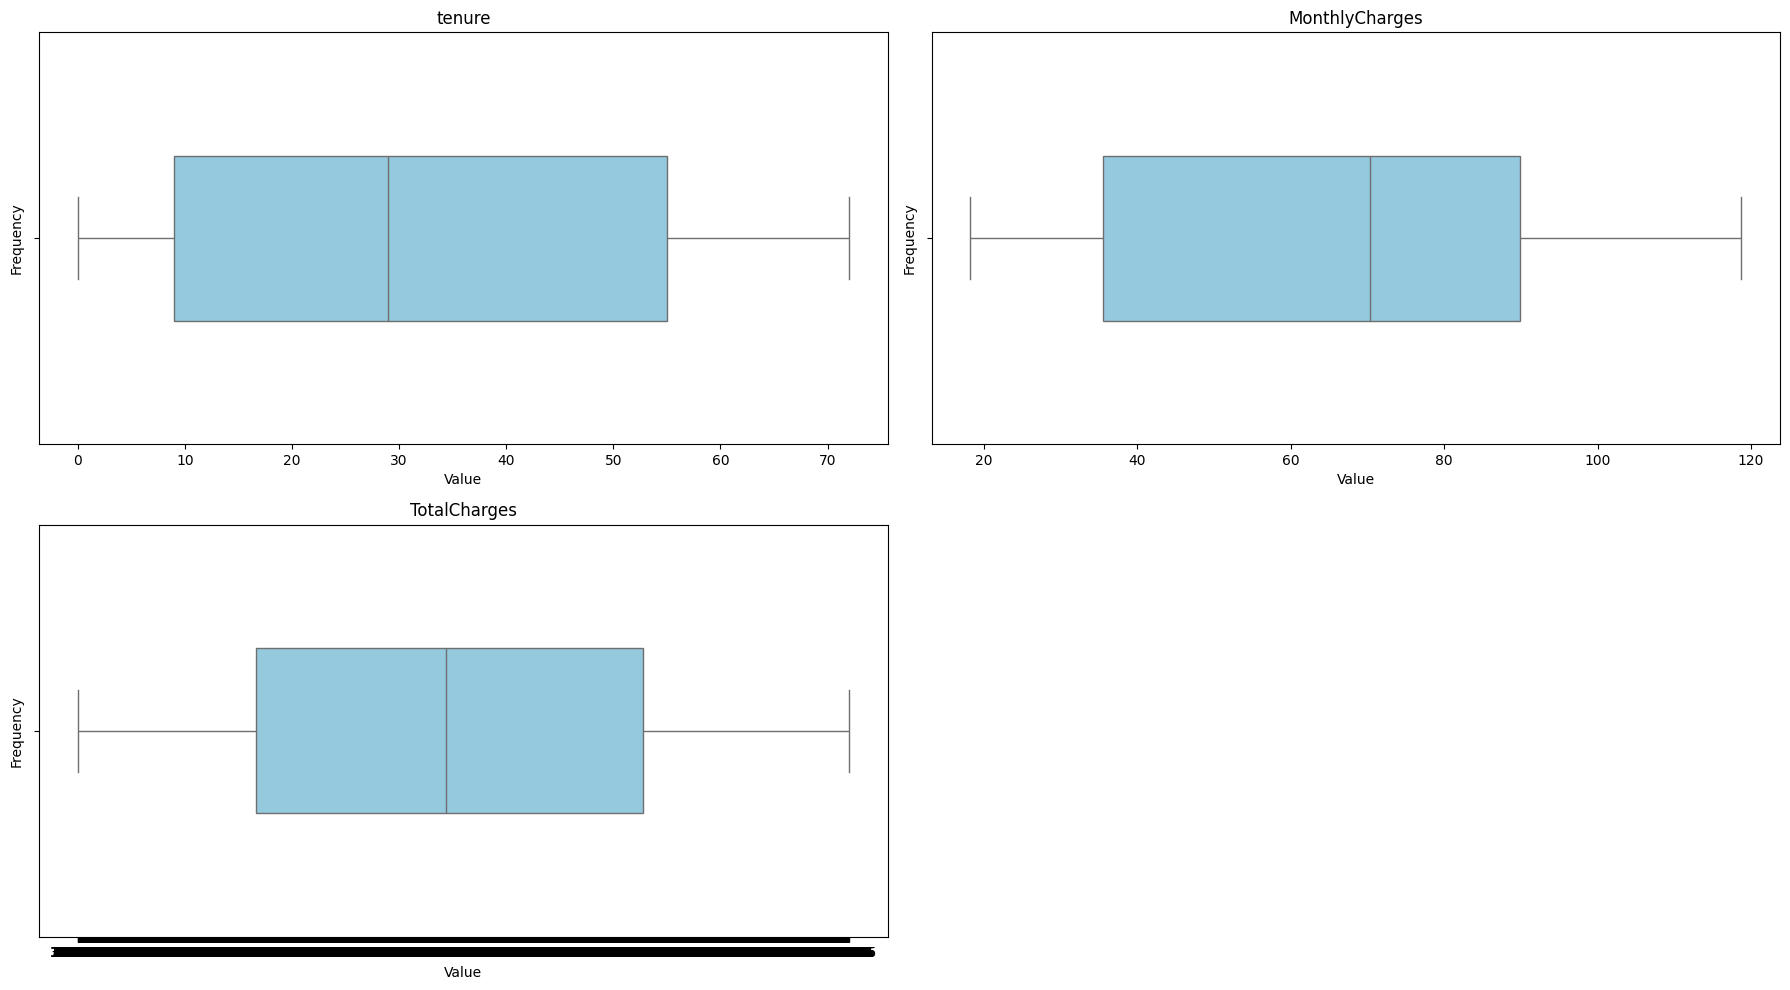

In [21]:
print("📦 Box plot for numerical features:")
plt.figure(figsize=(18, 10))

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, column in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=data[column], color='skyblue', width=0.4)
    plt.title(column)
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


#### Observation:
    
It does not look like there are many outliers in the numerical features, except Age - but we can't do much about it

📊 Count plot for categorical features:


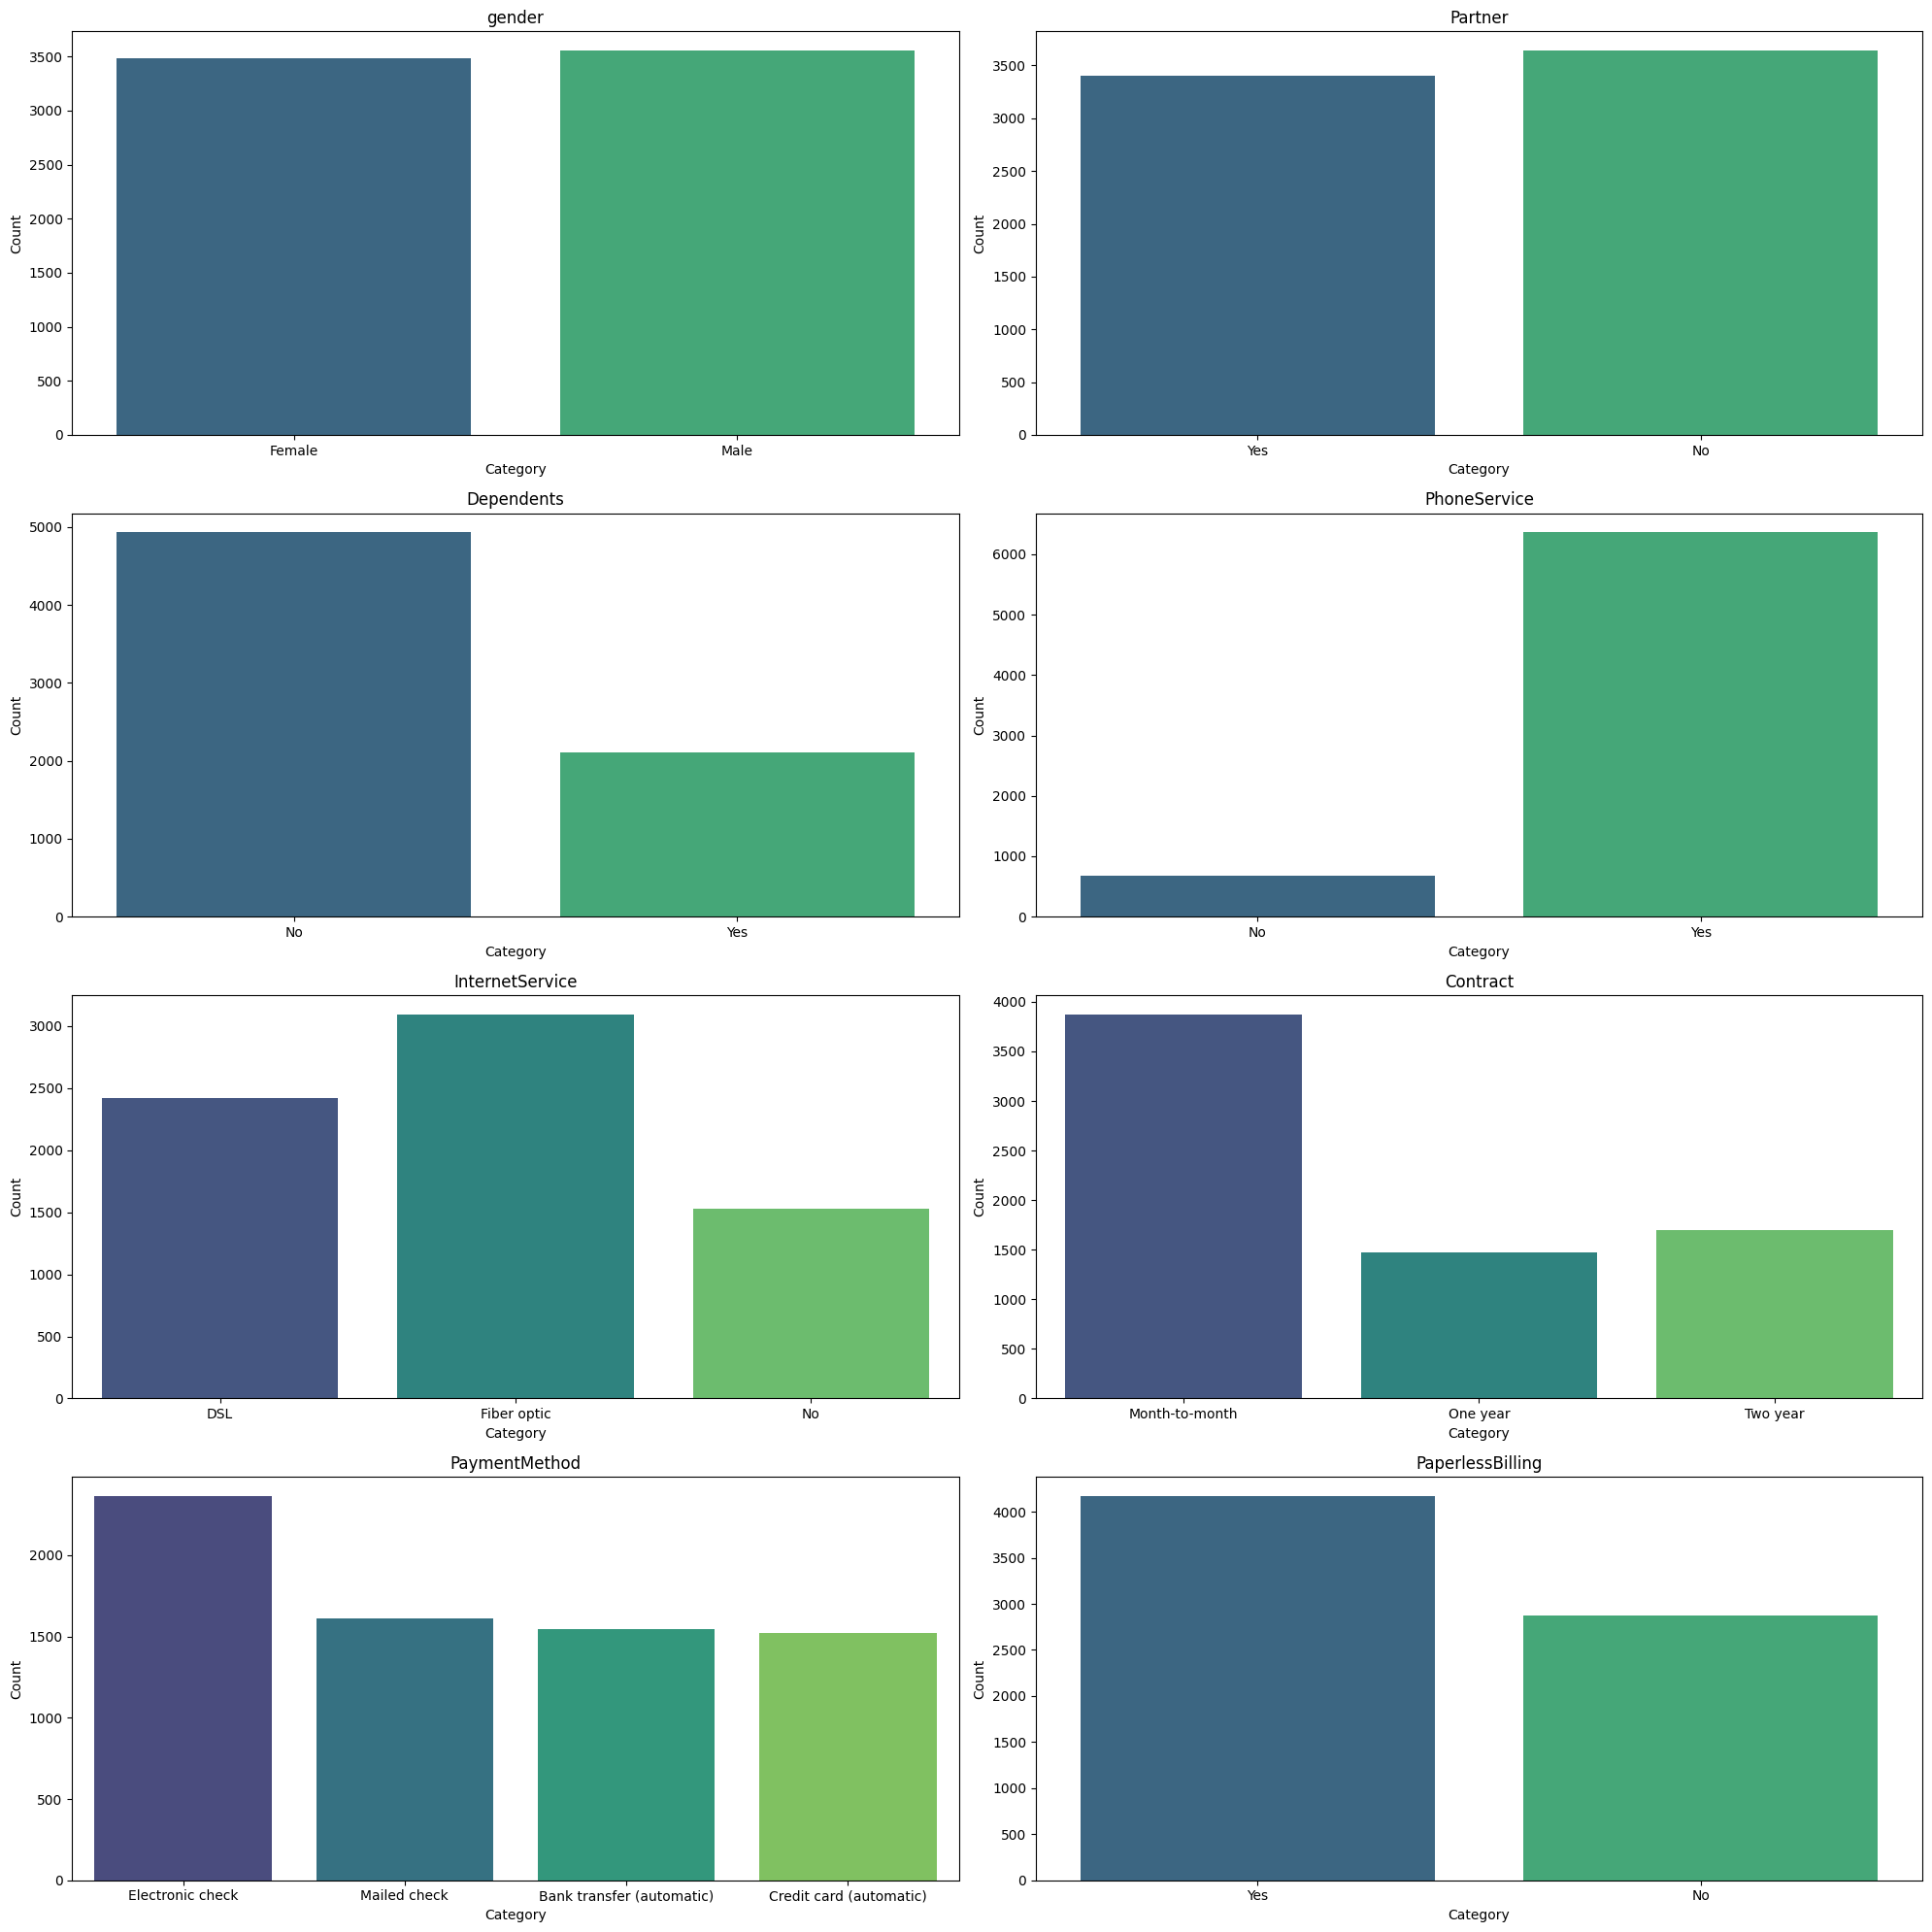

In [22]:
print("📊 Count plot for categorical features:")
plt.figure(figsize=(20, 20))

categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'InternetService', 'Contract', 'PaymentMethod', 'PaperlessBilling'
]

for i, column in enumerate(categorical_features):
    plt.subplot(4, 2, i + 1)
    sns.countplot(x=column, data=data, palette='viridis')
    plt.title(column)
    plt.xlabel('Category')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


#### Observation:
    
The count plots indicate that there are more customers from France than Spain or Germany, the gender distribution is nearly balanced, most customers have a credit card, and there is a higher proportion of active members

📊 Observing numerical variables based on the Churn column:


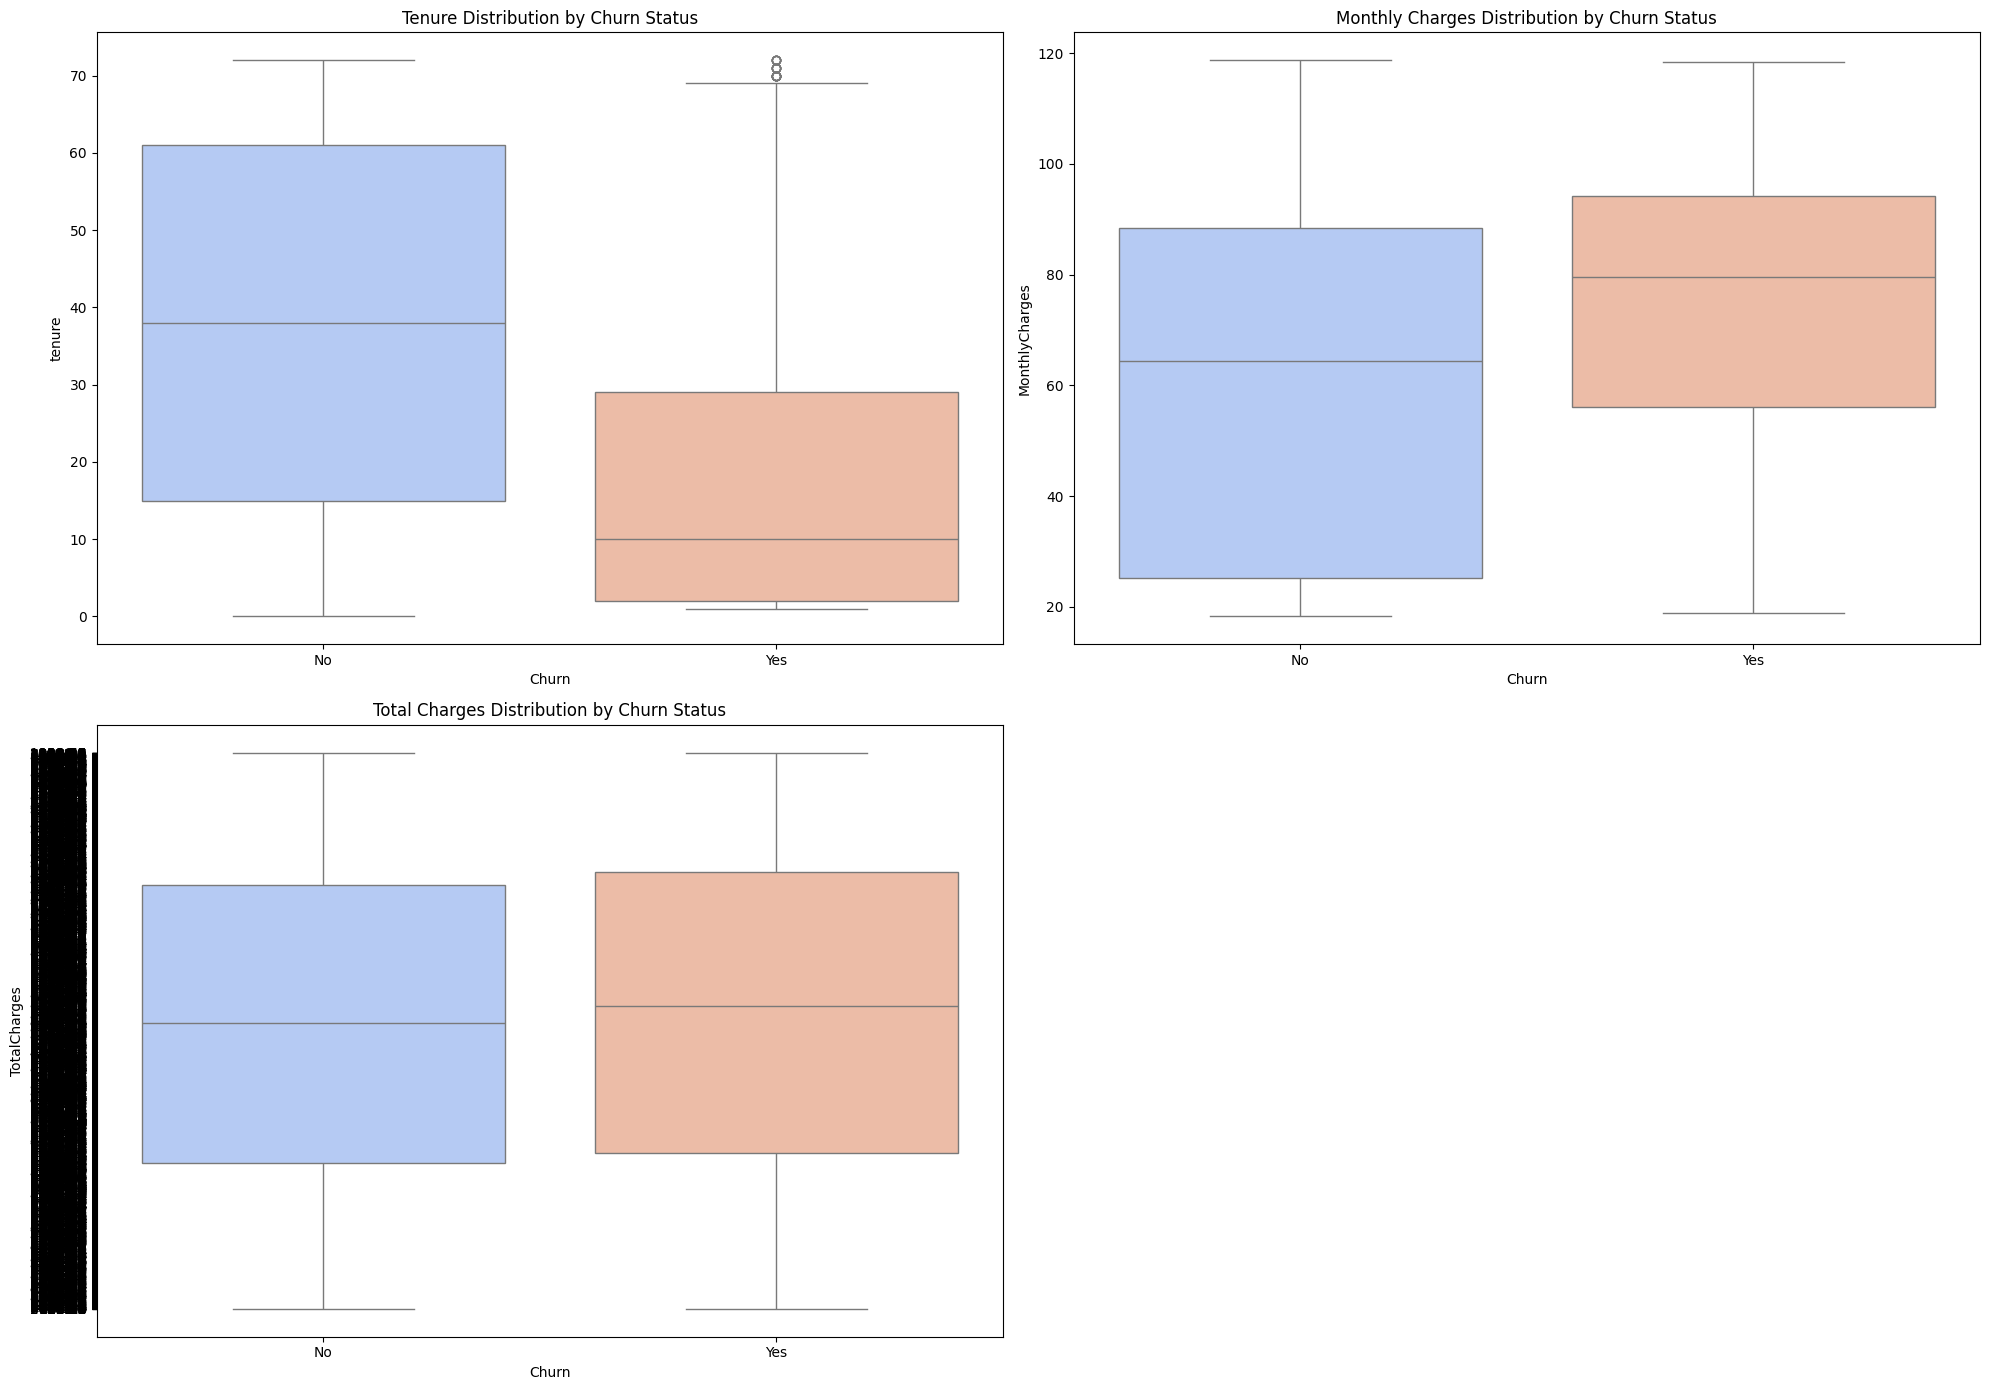

In [24]:
print("📊 Observing numerical variables based on the Churn column:")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

sns.boxplot(data=data, y='tenure', x='Churn', ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Tenure Distribution by Churn Status')

sns.boxplot(data=data, y='MonthlyCharges', x='Churn', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Monthly Charges Distribution by Churn Status')

sns.boxplot(data=data, y='TotalCharges', x='Churn', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Total Charges Distribution by Churn Status')

axes[1, 1].axis('off')  # Leave one plot empty for layout balance
plt.tight_layout()
plt.show()


#### Observation:

The credit score distribution between customers who churned and those who did not churn is similar, indicating that the credit score may not be a strong predictor of churn.

The tenure distribution suggests that customers with a shorter tenure are slightly more likely to churn than those with a longer tenure.

Age distribution shows a more pronounced difference - older customers appear more likely to churn than younger ones.

Lastly, the balance distribution is significantly different, with churned customers having higher balances on average. This could indicate that customers with higher balances are at a higher risk of churn.

The estimated salary distribution does not show a stark difference between the churned and retained customers, suggesting that salary may not be a primary factor in the decision to churn.

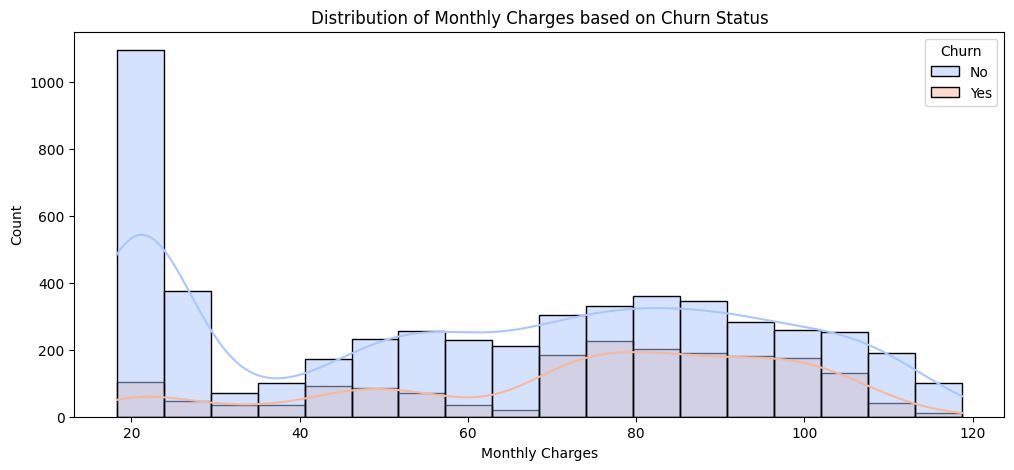

In [25]:
plt.figure(figsize=(12, 5))
sns.histplot(data=data, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('Distribution of Monthly Charges based on Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()


#### Observation:

By observing the distribution of credit scores among customers who have churned versus those who haven't, we can see that there is no stark contrast between the two groups, implying that credit score alone may not be a strong predictor of churn within this dataset.

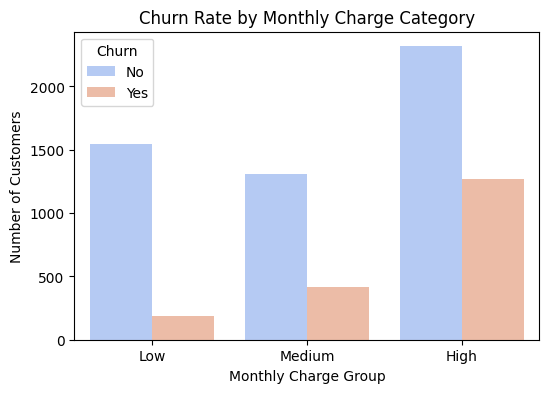

In [26]:
# Create bins for MonthlyCharges
bins = [0, 35, 70, 120]
labels = ['Low', 'Medium', 'High']

data['MonthlyChargeGroup'] = pd.cut(data['MonthlyCharges'], bins=bins, labels=labels, include_lowest=True)

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='MonthlyChargeGroup', hue='Churn', data=data, palette='coolwarm')
plt.title('Churn Rate by Monthly Charge Category')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Number of Customers')
plt.show()


#### Observation:

Majority of customers who churned are in the 'High' credit score group, suggesting that credit score might have some influence on churn, albeit not a straightforward one

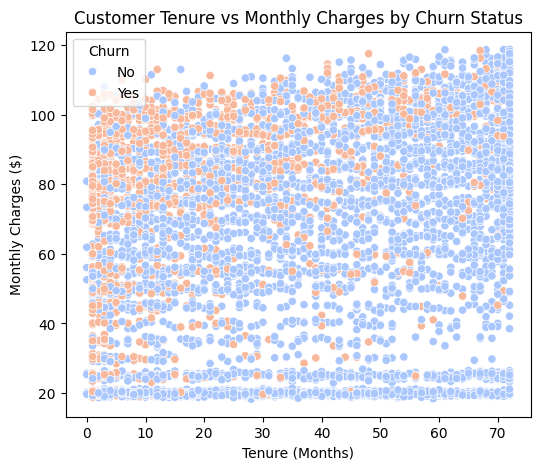

In [27]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=data, palette='coolwarm')
plt.title('Customer Tenure vs Monthly Charges by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.show()


#### Observation:

The scatter plot indicates that there is no clear pattern or correlation between tenure and balance for both churned and retained customers, implying these factors independently do not strongly predict customer churn

## Feature Engineering

### *Exploring the relationship between features*

a. **Credit Utilization**: Ratio of balance to credit score. It can give an insight into how much of the available credit the customer is using

b. **Interaction Score**: A composite score based on the number of products, active membership, and credit card possession which can give a holistic view of a customer's engagement with the bank. Higher engagement levels might be associated with lower churn rates

c. **Balance To Salary Ratio**: Ratio of the customer's balance to their estimated salary. This feature can indicate how significant the customer's balance is in relation to their income

d. **Credit Score Age Interaction**: An interaction term between credit score and age to explore if the impact of credit score on churn varies across different age groups

In [28]:
# Convert TotalCharges to numeric if it's not already
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# 1️⃣ Average Monthly Spend per Tenure Month
data['AvgChargesPerMonth'] = data['TotalCharges'] / (data['tenure'] + 1)

# 2️⃣ Senior + Internet service interaction
data['SeniorInternetCombo'] = data['SeniorCitizen'] * data['InternetService'].apply(lambda x: 1 if x != 'No' else 0)

# 3️⃣ Binary flag: Long-term contract or not
data['IsLongTermContract'] = data['Contract'].apply(lambda x: 1 if x in ['One year', 'Two year'] else 0)

# 4️⃣ Service count — total number of “Yes” services
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

data['TotalServices'] = data[services].apply(lambda row: sum(row == 'Yes'), axis=1)

data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyChargeGroup,AvgChargesPerMonth,SeniorInternetCombo,IsLongTermContract,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,Low,14.925000,0,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,Medium,53.985714,0,1,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,Medium,36.050000,0,0,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,Medium,40.016304,0,1,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,High,50.550000,0,0,1


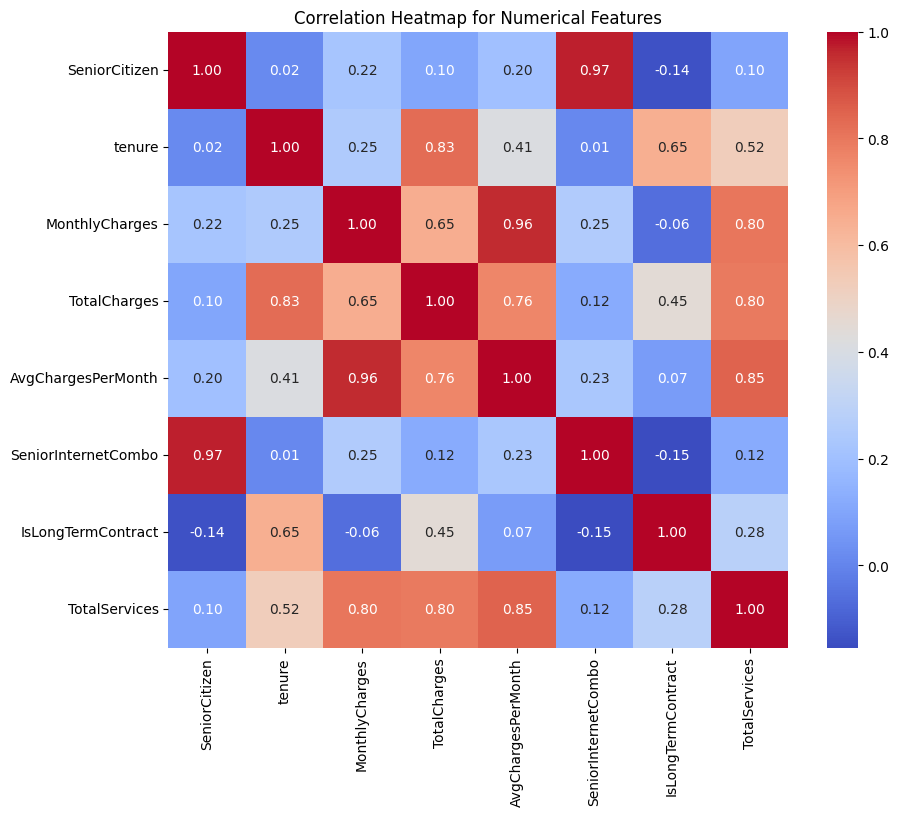

In [29]:
plt.figure(figsize=(10, 8))

# Select only numeric columns
numeric_df = data.select_dtypes(include=['float64', 'int64'])

# Plot correlation heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap for Numerical Features')
plt.show()


#### Observations:

Notable correlations include a moderate positive relationship between Age and Exited, suggesting older customers are more likely to churn, and a strong positive relationship between Balance and CreditUtilization, which is intuitive as higher balances would likely increase credit utilization rates

In [30]:
# Convert target column to numeric
data['Churn'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select only numeric columns for correlation
numeric_df = data.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Extract correlations with target variable
target_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

print("🔍 Correlation of features with Churn:\n")
print(target_correlations)


🔍 Correlation of features with Churn:

Churn                  1.000000
MonthlyCharges         0.193356
SeniorInternetCombo    0.161594
SeniorCitizen          0.150889
AvgChargesPerMonth     0.070992
TotalServices         -0.067264
TotalCharges          -0.199484
tenure                -0.352229
IsLongTermContract    -0.405103
Name: Churn, dtype: float64


#### Observation:

1. Age shows a moderately positive correlation, suggesting older customers are more likely to churn 
2. IsActiveMember has a negative correlation, indicating that active members are less likely to churn
3. High CreditUtilization and NumOfProducts also appear to be associated with a higher likelihood of churning

## Modeling

In [31]:
cat_col = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'PaymentMethod'
]

print("📊 Observing the categorical column distribution before encoding:\n")
for column in cat_col:
    print(f"--- {column} ---")
    print(data[column].value_counts(), "\n")


📊 Observing the categorical column distribution before encoding:

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64 

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64 

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

--- DeviceProtection ---
DeviceProtection
No   

In [32]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
encoder = LabelEncoder()

# Use your Telco dataset variable
for column in cat_col:
    data[column] = encoder.fit_transform(data[column])

print("✅ Observing categorical column distribution after encoding:\n")
for column in cat_col:
    print(f"--- {column} ---")
    print(data[column].value_counts(), "\n")


✅ Observing categorical column distribution after encoding:

--- gender ---
gender
1    3555
0    3488
Name: count, dtype: int64 

--- Partner ---
Partner
0    3641
1    3402
Name: count, dtype: int64 

--- Dependents ---
Dependents
0    4933
1    2110
Name: count, dtype: int64 

--- PhoneService ---
PhoneService
1    6361
0     682
Name: count, dtype: int64 

--- MultipleLines ---
MultipleLines
0    3390
2    2971
1     682
Name: count, dtype: int64 

--- InternetService ---
InternetService
1    3096
0    2421
2    1526
Name: count, dtype: int64 

--- OnlineSecurity ---
OnlineSecurity
0    3498
2    2019
1    1526
Name: count, dtype: int64 

--- OnlineBackup ---
OnlineBackup
0    3088
2    2429
1    1526
Name: count, dtype: int64 

--- DeviceProtection ---
DeviceProtection
0    3095
2    2422
1    1526
Name: count, dtype: int64 

--- TechSupport ---
TechSupport
0    3473
2    2044
1    1526
Name: count, dtype: int64 

--- StreamingTV ---
StreamingTV
0    2810
2    2707
1    1526
Name:

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 🎯 Define target and features
X = data.drop('Churn', axis=1)
y = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# ⚙️ Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 🔢 Select numeric columns to scale
scaling_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# Fit the scaler on training data only
scaler.fit(X_train[scaling_columns])

# Transform both train and test sets
X_train[scaling_columns] = scaler.transform(X_train[scaling_columns])
X_test[scaling_columns] = scaler.transform(X_test[scaling_columns])

print("✅ Data scaled and ready for model training!")


✅ Data scaled and ready for model training!


In [34]:
print("Training dataset shape:", X_train.shape, y_train.shape)
print("Test dataset shape:", X_test.shape, y_test.shape)


Training dataset shape: (4930, 25) (4930,)
Test dataset shape: (2113, 25) (2113,)


In [42]:
# ======================================================
# 📦 Import Libraries
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_pipeline_imb


# ======================================================
# 🧹 Prepare Data
# ======================================================
df = data.copy()  # ensure consistency if variable name was 'data'

# Handle TotalCharges (some blank strings cause errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target variable
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Drop unnecessary ID column
col_drop = ['customerID']
X = df.drop(col_drop + ['Churn'], axis=1)
y = df['Churn']


# Encode categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# ======================================================
# ✂️ Train-Test Split
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training class distribution:")
print(y_train.value_counts(), "\n")

# ======================================================
# ⚙️ Scale Numerical Columns
# ======================================================
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ======================================================
# 🤖 Define Models
# ======================================================
pos = sum(y_train)
neg = len(y_train) - pos
scale_pos_weight = neg / pos if pos != 0 else 1  # avoid ZeroDivisionError

models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': make_pipeline_imb(SMOTE(random_state=42), KNeighborsClassifier()),
    'Support Vector Machine': make_pipeline_imb(SMOTE(random_state=42), SVC(probability=True, random_state=42)),
    'XGBoost': XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ),
    'Gradient Boosting': make_pipeline_imb(SMOTE(random_state=42), GradientBoostingClassifier(random_state=42))
}

# ======================================================
# 📊 Evaluate Models
# ======================================================
results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Recall', 'F1', 'ROC AUC'])
lb = LabelBinarizer().fit(y_train)

for name, model in models.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(lb.transform(y_test), model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else None

    results_df.loc[len(results_df)] = [name, acc, rec, f1, roc]

print("\n✅ Final Model Performance Summary:")
print(results_df)


Training class distribution:
Churn
0    3622
1    1308
Name: count, dtype: int64 


Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113


Confusion Matrix:
[[1116  436]
 [ 114  447]]

Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1552
           1       0.60      0.46      0.52       561

    accuracy                           0.78      2113
   macro avg       0.71      0.67      0.69      2113
weighted avg       0.76      0.78      0.77      2113


Confusion Matrix:
[[1383  169]
 [ 304  257]]

Model: K-Nearest Neighbors

Classification Report:
              precisi

In [44]:
results_df

,Model,Accuracy,Recall,F1,ROC AUC
0,Logistic Regression,0.739707,0.796791,0.619114,0.842168
1,Random Forest,0.776148,0.458111,0.520770,0.816276
2,K-Nearest Neighbors,0.710838,0.741533,0.576577,0.773449
3,Support Vector Machine,0.746805,0.746881,0.610342,0.820713
4,XGBoost,0.757690,0.663102,0.592357,0.812482
5,Gradient Boosting,0.758637,0.754011,0.623894,0.832669


From the results of the classification models on the churn prediction dataset, we can infer the following:

1. **Gradient Boosting** has the highest F1 score (0.598391) and the highest ROC AUC score (0.859767) among all the models. This suggests that Gradient Boosting is the most effective model in balancing precision and recall and has the best ability to distinguish between the churned and non-churned customers.

2. **XGBoost** also performs well, with a relatively high F1 score (0.586974) and a good ROC AUC score (0.841784). This indicates that XGBoost is another strong model for this task.

3. **Random Forest** has a high accuracy (0.862000) but a lower F1 score (0.538976) compared to Gradient Boosting and XGBoost. This suggests that while Random Forest is good at predicting the majority class (non-churned customers), it might not be as effective at identifying the minority class (churned customers).

4. **Support Vector Machine** and **K-Nearest Neighbors** have moderate F1 scores and ROC AUC scores. They perform better than Logistic Regression but are not as effective as Gradient Boosting or XGBoost for this dataset.

5. **Logistic Regression** has the lowest accuracy (0.703667), F1 score (0.473029), and ROC AUC score (0.764076) among all the models. This indicates that Logistic Regression is the least effective model for predicting customer churn in this dataset.

#### Overall:

Gradient Boosting appears to be the best model for this churn prediction task, followed closely by XGBoost. These models are able to better handle the class imbalance and provide a good balance between precision and recall. 